<a href="https://colab.research.google.com/github/emilleishida/Fink_earlyTDE_v2/blob/main/notebooks/check_the_fits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
# Run to download necessary files and clone & install light-curve repository

import pathlib
import os

data_dir = '/content'
pathlib.Path(data_dir).mkdir(parents=True, exist_ok=True)

files_to_download = {
    os.path.join(data_dir, "feature_data.csv"): "1JRhA1Nc0zC4OhK52UerBeVUTV98h8SIE",
    os.path.join(data_dir, "mallorn_data_fink_SNR_30d_LCs.pkl"): "1bb1fgySX2KRMFxWLzSpFbLfq3vUOtWtj",
    #os.path.join(data_dir, "mallorn_data_fink_SNR_Full_LCs.pkl"): "1DNk-sk3a2fC1v8dCx6KqyHDjtxMLWi2W",
}


for fpath, fid in files_to_download.items():
    url = f"https://drive.google.com/uc?id={fid}"
    if not os.path.exists(fpath):
        print(f"Downloading {os.path.basename(fpath)}...")
        !gdown "{url}" -O "{fpath}"
    else:
        print(f"{os.path.basename(fpath)} already exists, skipping.")




Downloading...
From: https://drive.google.com/uc?id=1JRhA1Nc0zC4OhK52UerBeVUTV98h8SIE
To: /content/feature_data.csv
100% 7.27M/7.27M [00:00<00:00, 17.3MB/s]
mallorn_data_fink_SNR_30d_LCs.pkl already exists, skipping.


In [59]:
try:
  from light_curve.light_curve_py import RainbowFit
except ModuleNotFoundError:

  !git clone https://github.com/light-curve/light-curve-python.git
  !pip install 'light-curve[full]'
  from light_curve.light_curve_py import RainbowFit


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from light_curve import RainbowFit

band_wave_aa = {  # Wavelenght in angstrom for Rainbow in LSST
      "u": 3671.0,
      "g": 4827.0,
      "r": 6223.0,
      "i": 7546.0,
      "z": 8691.0,
      "y": 9712.0,
  }
model = RainbowFit.from_angstrom(
    band_wave_aa,
    with_baseline=False,
    temperature="constant",
    bolometric="sigmoid",
)

colors = [
    "blue",
    "orange",
    "green",
    "red",
    "purple",
    "brown"
]

names = ['reference_time', 'amplitude', 'rise_time', 'temperature']

/usr/local/lib/python3.12/dist-packages/light_curve/light_curve_py/warnings.py:19: ExperimentalWarning: Function light_curve.light_curve_py.features.rainbow.generic.RainbowFit is experimental and may cause any kind of troubles
  warn_experimental(message)


In [61]:
def load_features(filename, keep_only_last_alert = False, apply_quality_cuts=True):

  features = pd.read_csv(filename)
  features = features.dropna()
  if apply_quality_cuts:
     features = features[features.passes_feature_quality_cuts]
  if keep_only_last_alert:
    features = features.sort_values("jd_max", ascending = False)
    features = features.drop_duplicates("object_id")

  return features

# Load features keeping only the last alert
features = load_features("feature_data.csv", keep_only_last_alert = True)

# Light curve
lcs = pd.read_pickle("mallorn_data_fink_SNR_30d_LCs.pkl")
lcs['full_lightcurve'] = lcs.apply(lambda x: pd.concat([x['lightcurve_preprocessed_30d'], x['lightcurve']]), axis=1)

# Add redsfhit column to the features
features = features.merge(lcs[["object_id", "redshift"]], on="object_id", how="left")

# Take TDEs
lcs_tdes = lcs[lcs['SpecType']=='TDE']
lcs_tdes = lcs_tdes[lcs_tdes['object_id'].isin(features['object_id'])]

# Take only SNe with bad chisq
features_bad_chisq = features[features['r_chisq']>9]
lcs_sn = lcs[(lcs['SpecType']!='AGN') & (lcs['SpecType']!='TDE')]
lcs_sn = lcs_sn[lcs_sn['object_id'].isin(features_bad_chisq['object_id'])]




In [79]:

def generate_plots(lcs, features):
    for objid in np.unique(lcs['object_id']):

        lc = lcs[lcs['object_id']==objid].iloc[0]['full_lightcurve']
        feature = features[features['object_id']==objid].iloc[0]

        plt.figure()

        for idx, band in enumerate(np.unique(lc["filter"])):

            mask_band = (lc["filter"] == band)

            mask_good = mask_band & lc["detection_5SNR"]
            mask_bad  = mask_band & ~lc["detection_5SNR"]

            # --- GOOD points (SNR > 5)
            plt.errorbar(
                lc["mjd"][mask_good],
                lc["flux_dered"][mask_good],
                yerr=lc["flux_err_dered"][mask_good],
                fmt="o",
                color=colors[idx],
                label=band
            )

            # --- BAD points (SNR <= 5)
            plt.errorbar(
                lc["mjd"][mask_bad],
                lc["flux_dered"][mask_bad],
                yerr=lc["flux_err_dered"][mask_bad],
                fmt="x",
                color=colors[idx],
                alpha=0.3,        # more transparent
                markersize=4,     # smaller
            )

            # --- Model
            time = lc["mjd"][mask_band]
            time_smooth = np.linspace(np.min(time)-60, np.max(time)+10, 500)

            fit = model.model(time_smooth, band, *feature[names].values)

            plt.plot(time_smooth, fit, color=colors[idx])

        # Let´s also show the 30-day interval with DR photometry also used for the fit.
        lc_30d = lcs[lcs['object_id']==objid].iloc[0]['lightcurve_preprocessed_30d']
        t_min_30d = lc_30d['mjd'].min()
        t_max_30d = lc_30d['mjd'].max()

        plt.axvspan(t_min_30d, t_max_30d,	color="gray",	alpha=0.15, label="ForcedPhot window")

        # Plot style
        plt.title('%s (%s)'%(feature['object_id'], feature['SpecType']))
        plt.ylim(bottom=-1)
        #peak_time = lc['mjd'].iloc[np.argmax(lc['flux_dered'])]
        # if objid != 'achas_saer_hand':
        #     plt.xlim(peak_time - 100, peak_time + 5)
        plt.xlim(np.min(lc["mjd"][lc["detection_5SNR"]]) -40,  feature['jd_max'] + 20)

        plt.axvline(feature['jd_max'], c='grey', ls='dashed', label= 'jd_max')

        # Add to the legend
        plt.plot([], [], "x",	color="gray",	alpha=0.3, markersize=4, label="SNR < 5")

        plt.legend()





# **Plot  TDEs**

/tmp/ipykernel_1847/3185497804.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


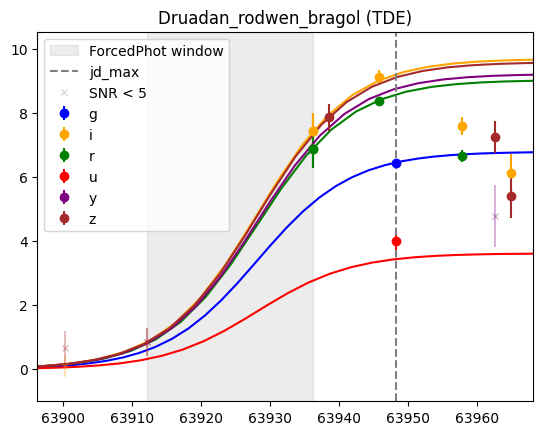

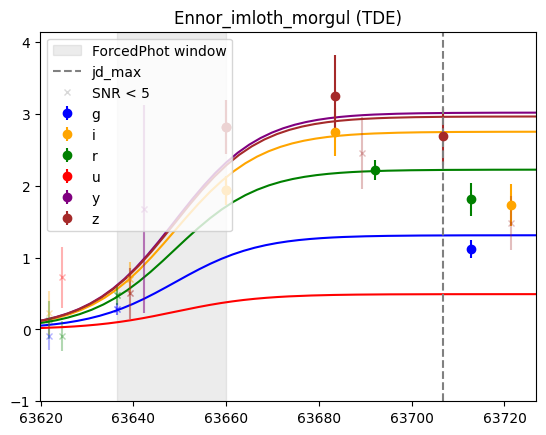

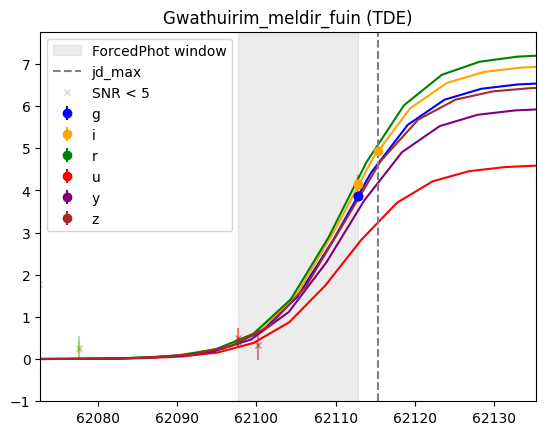

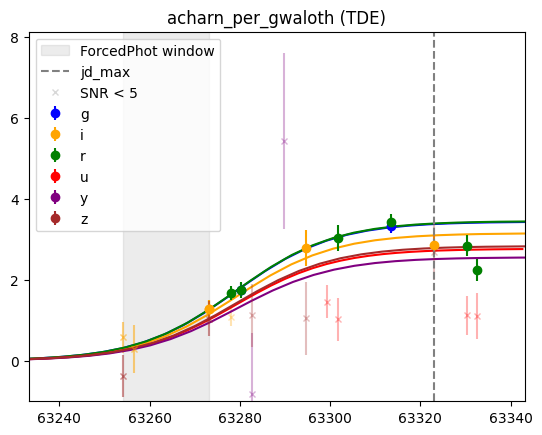

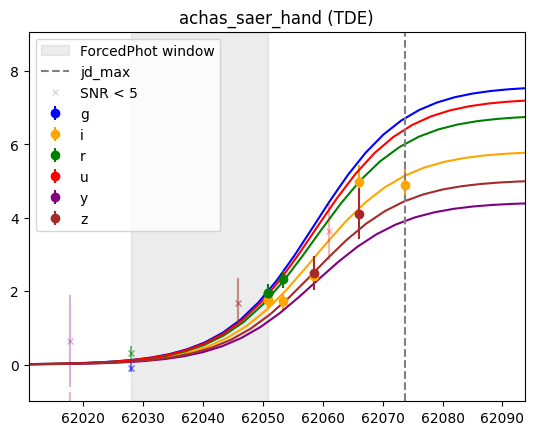

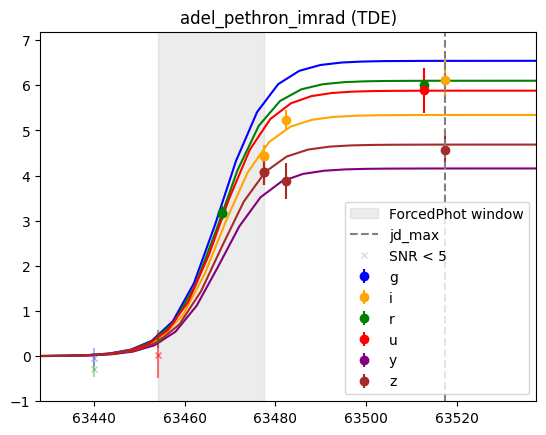

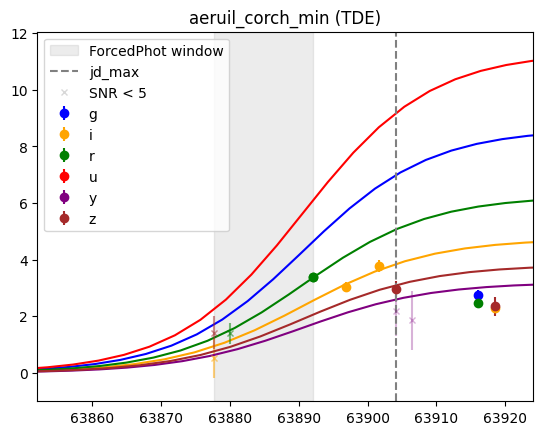

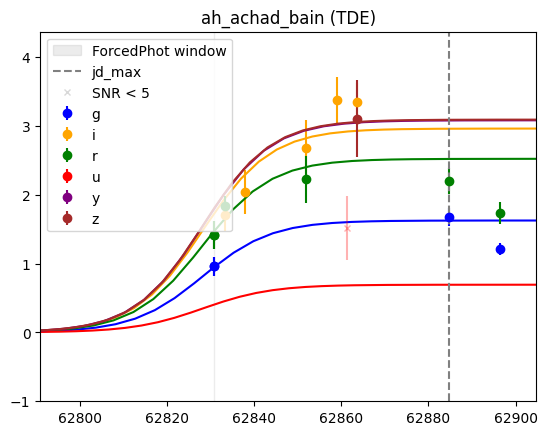

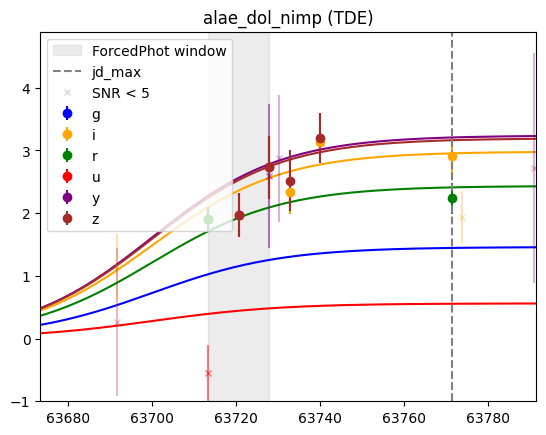

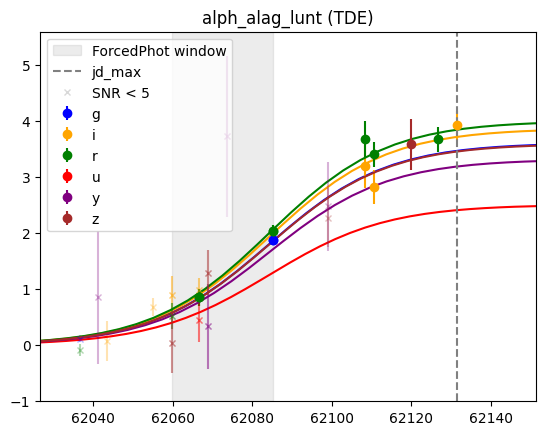

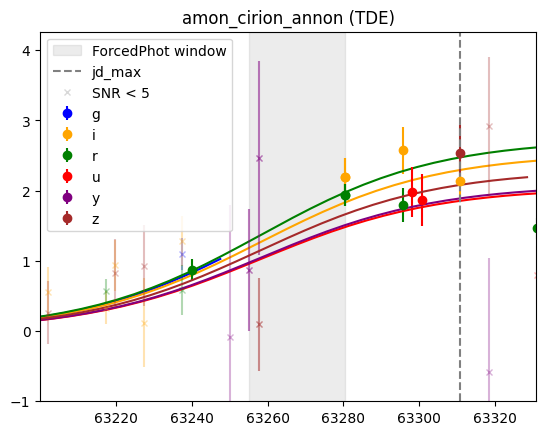

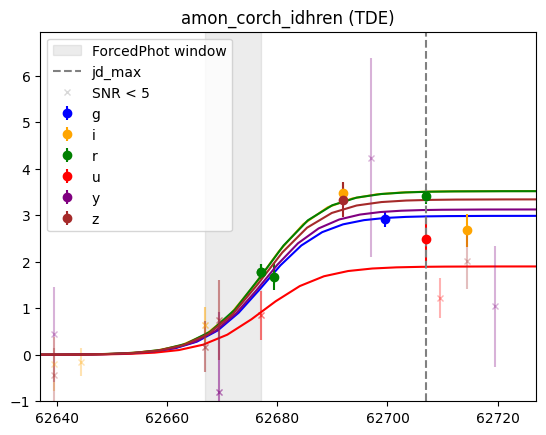

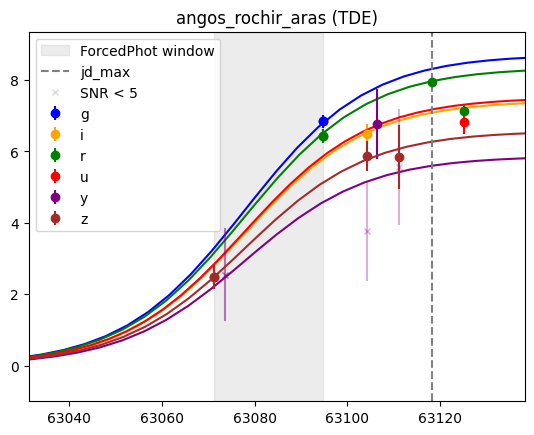

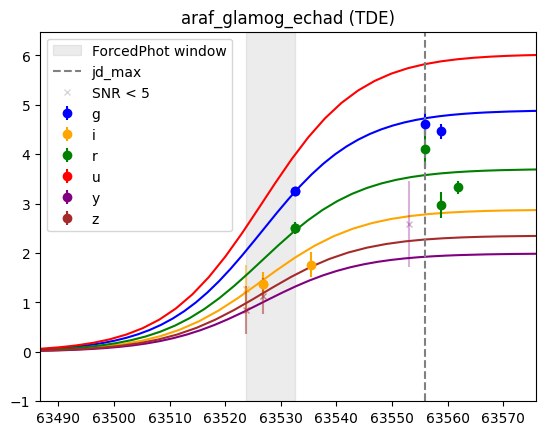

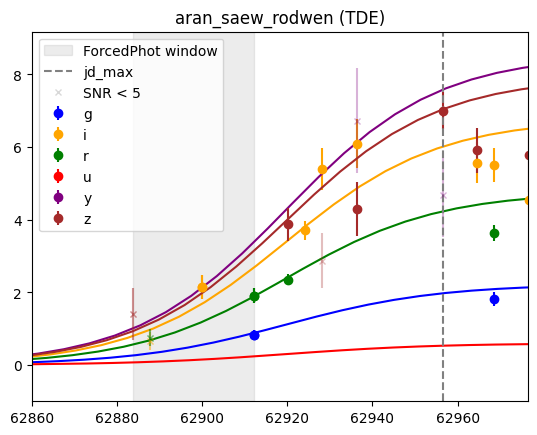

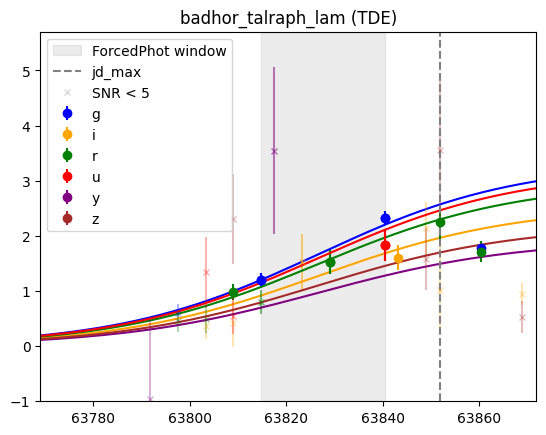

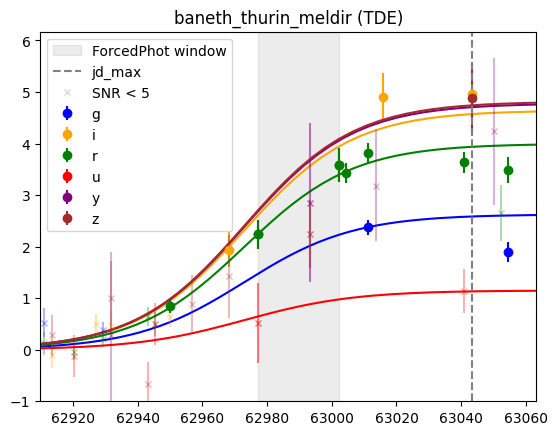

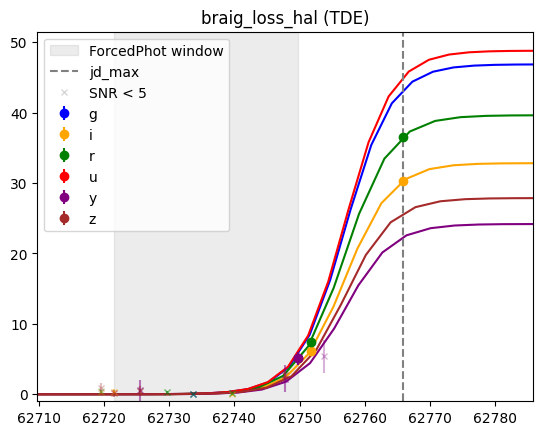

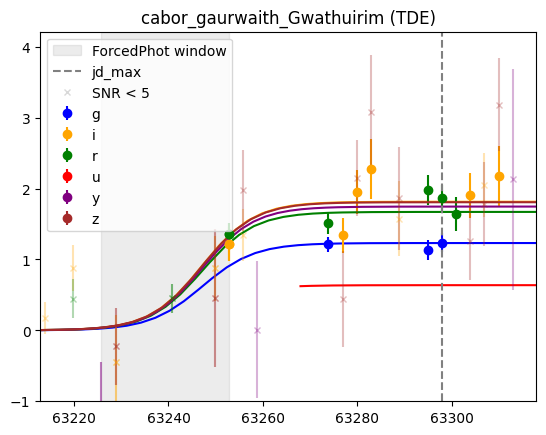

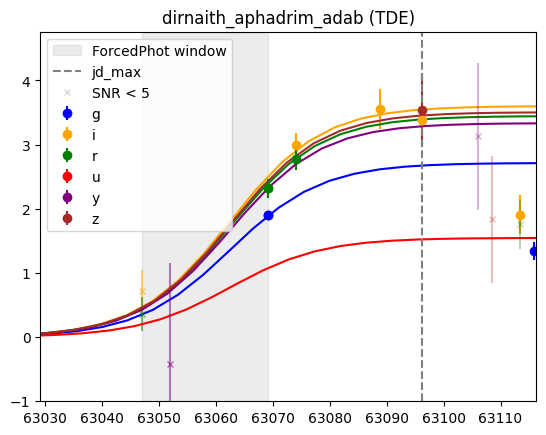

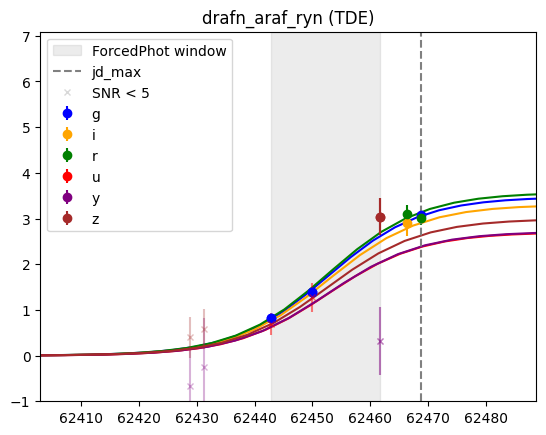

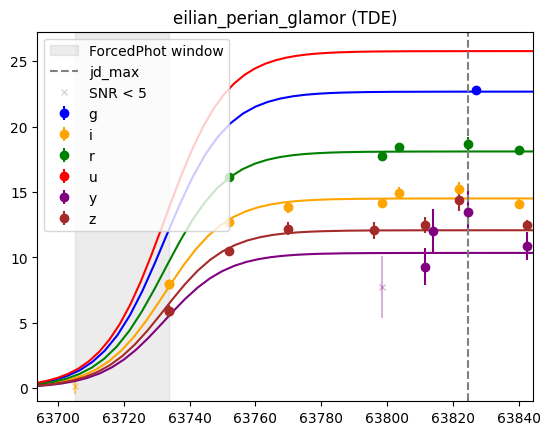

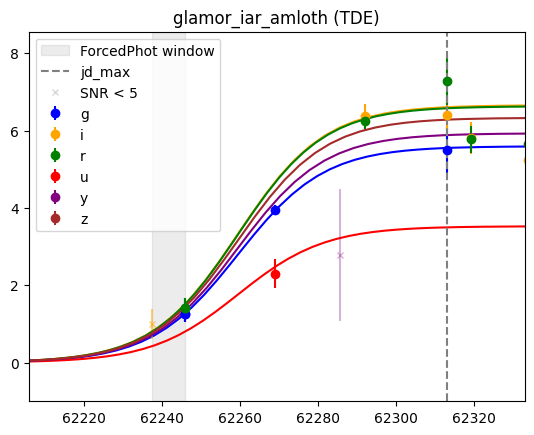

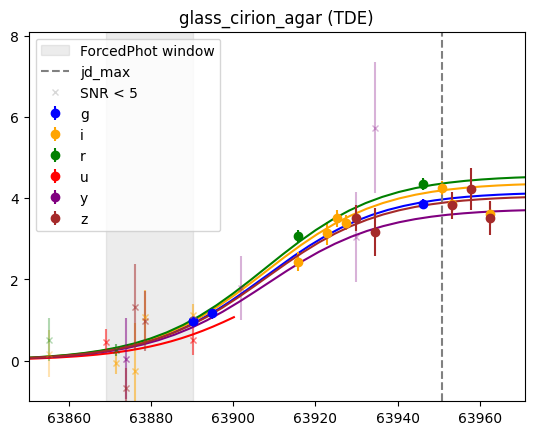

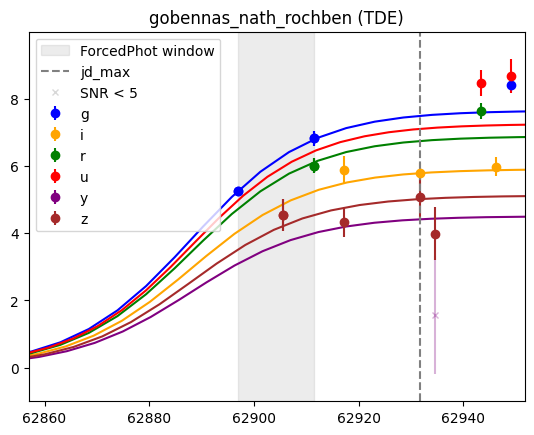

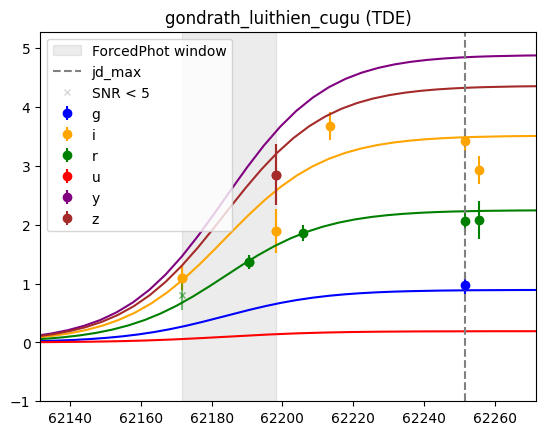

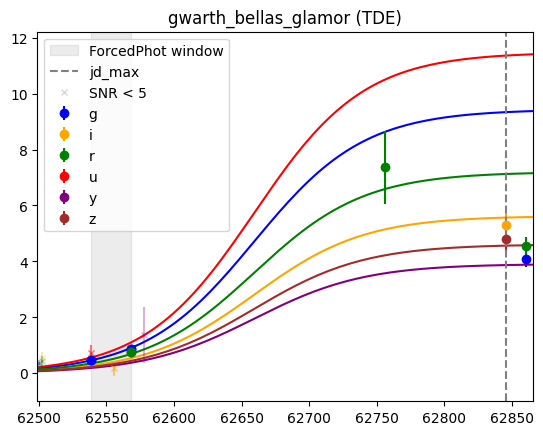

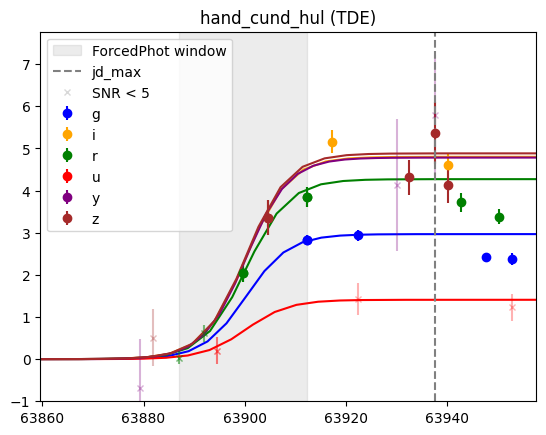

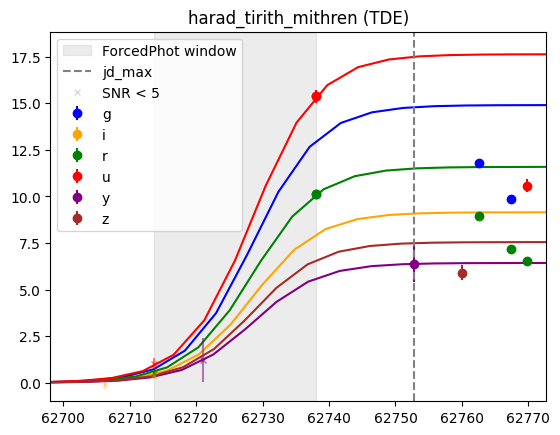

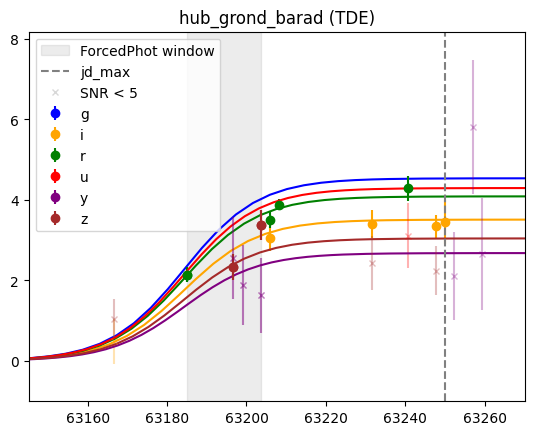

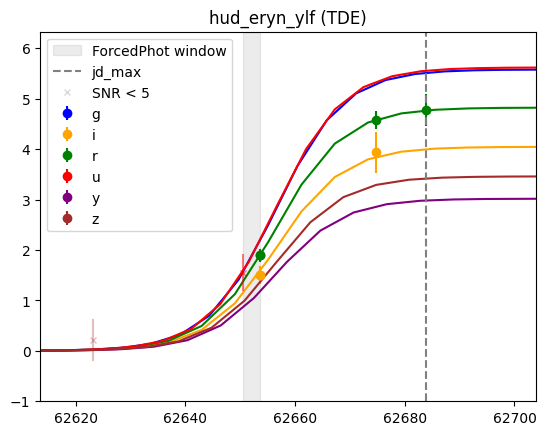

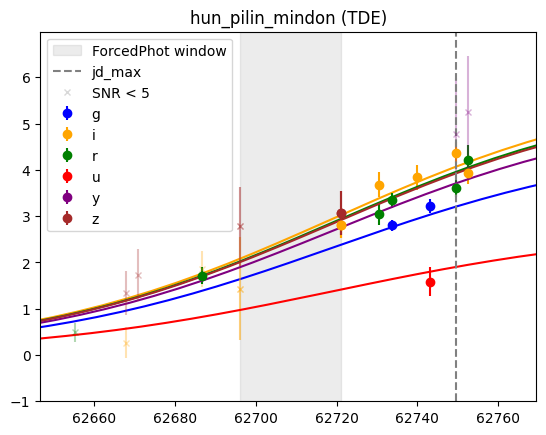

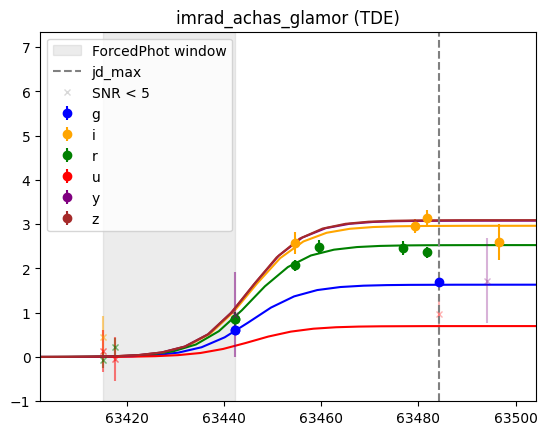

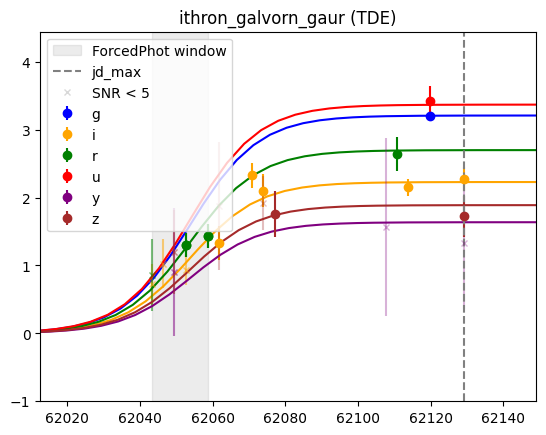

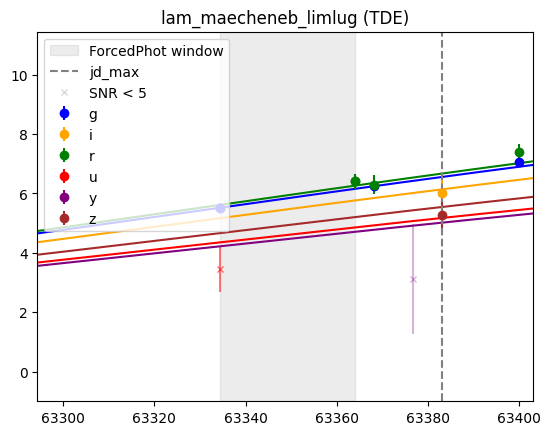

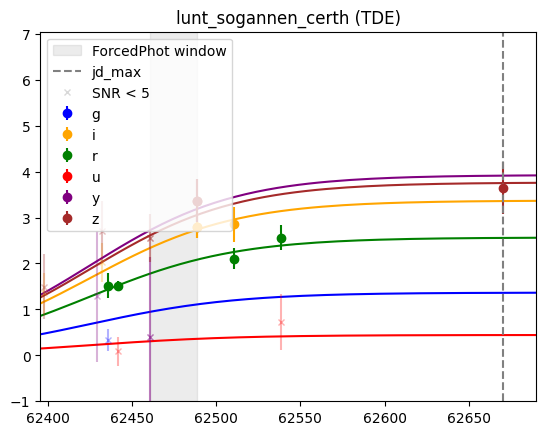

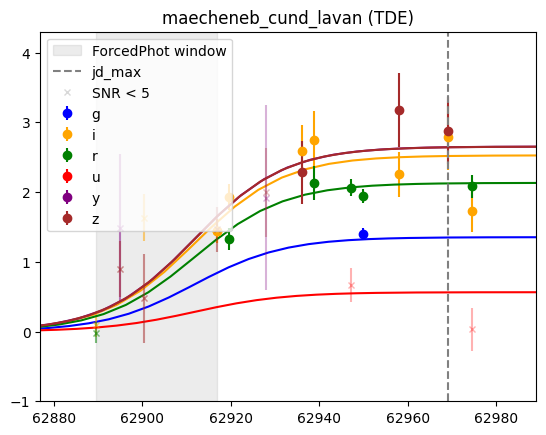

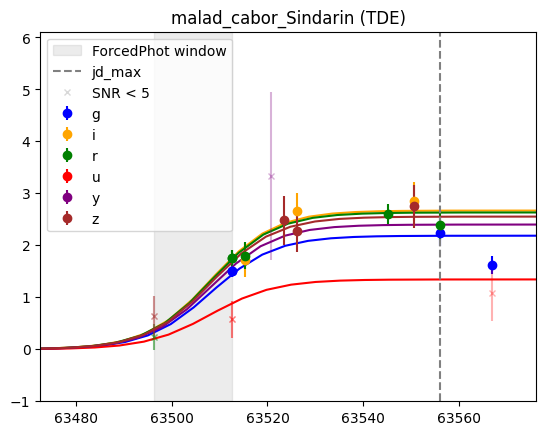

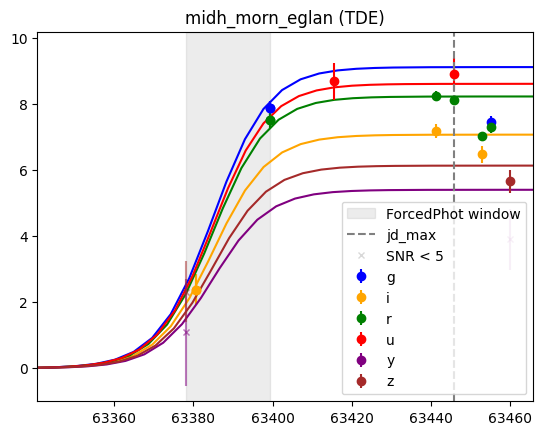

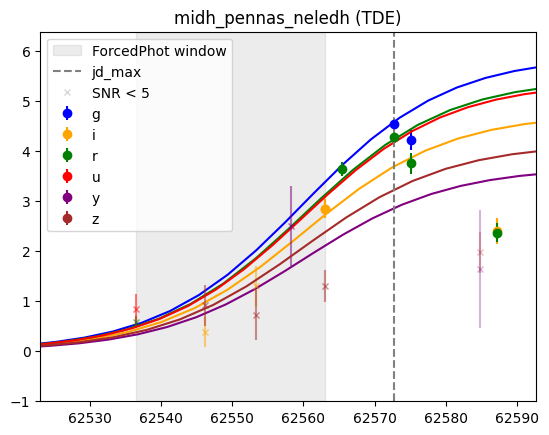

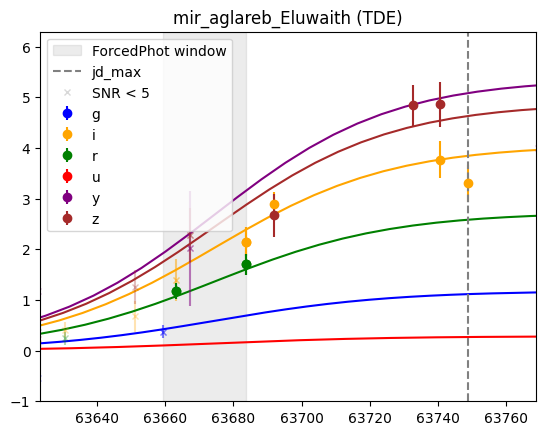

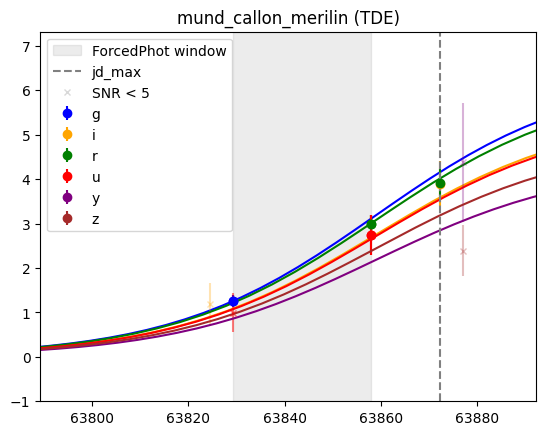

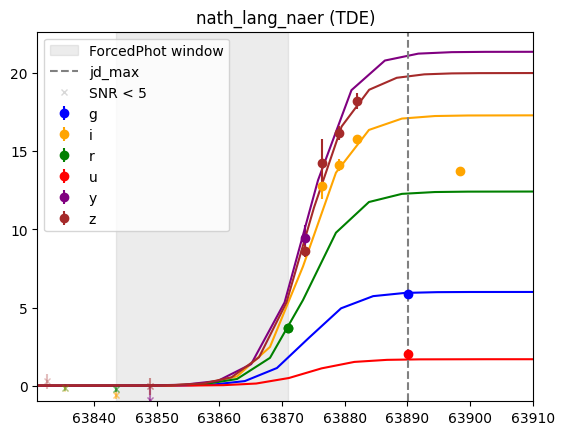

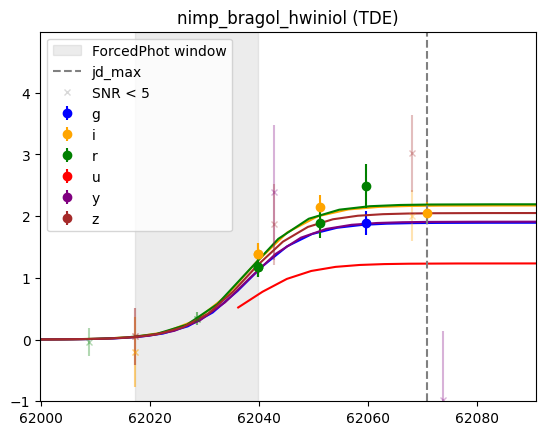

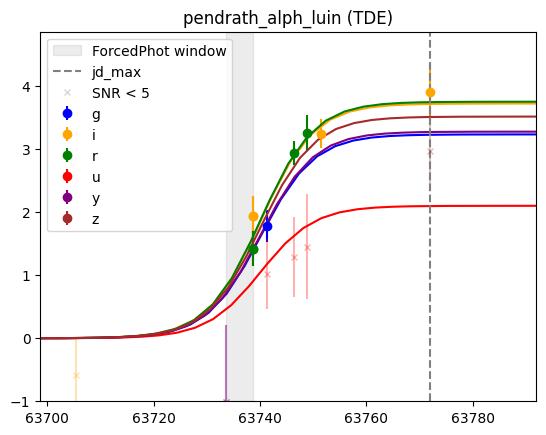

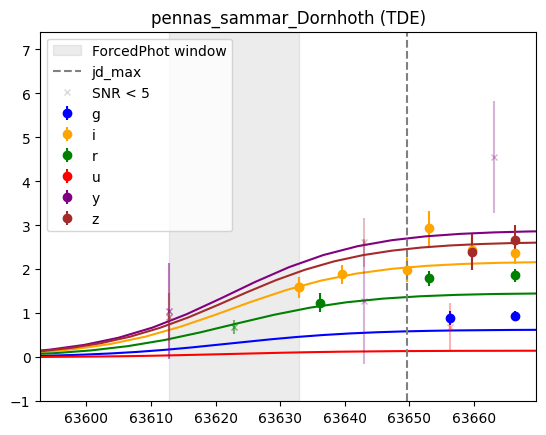

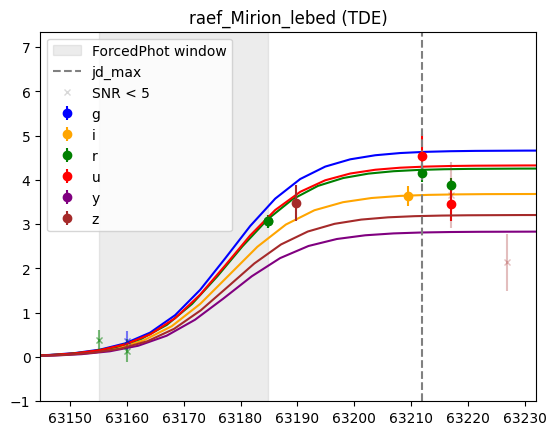

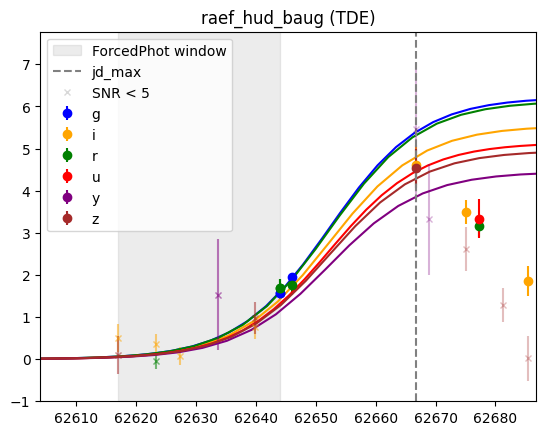

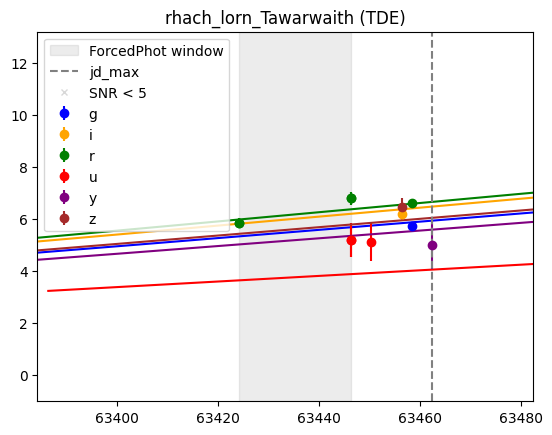

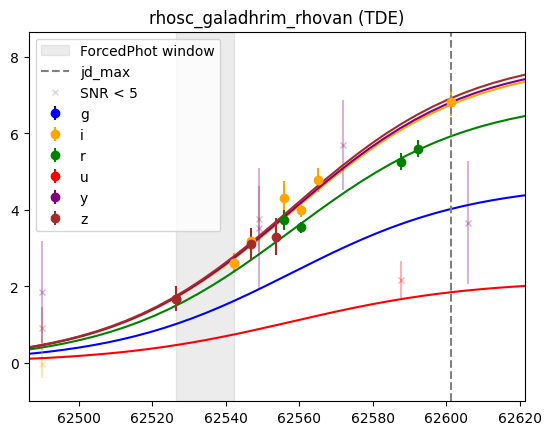

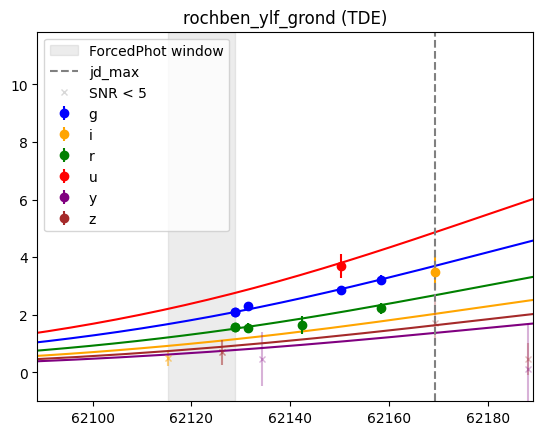

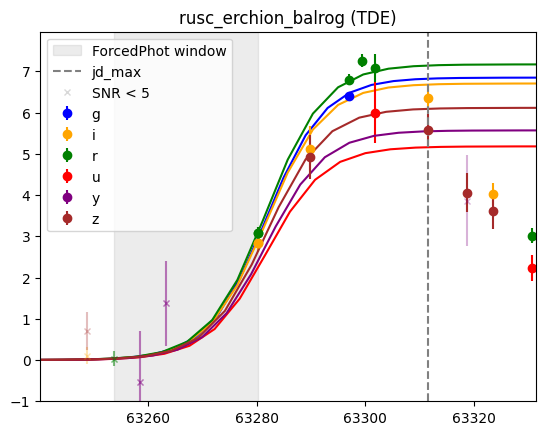

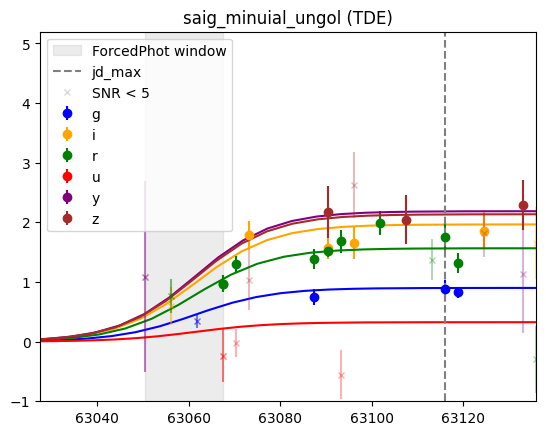

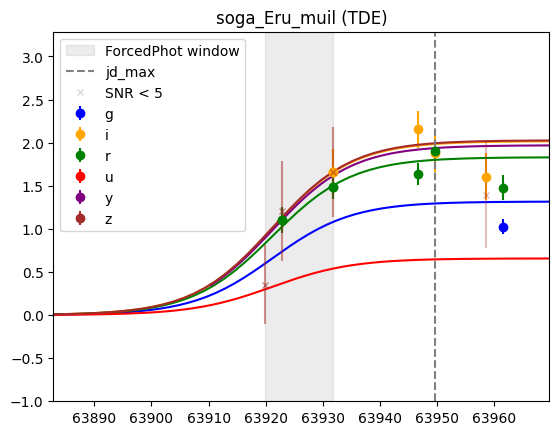

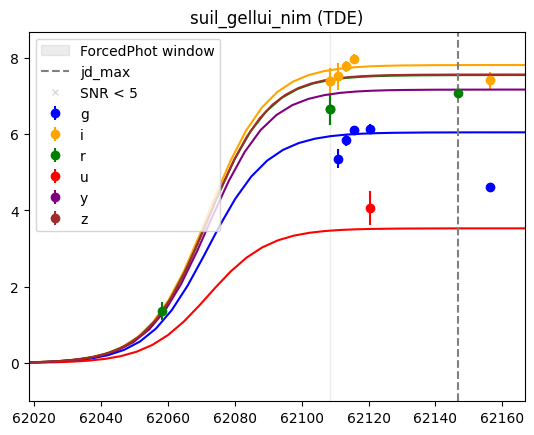

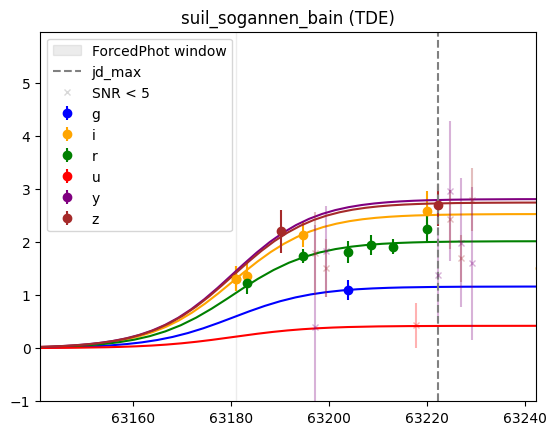

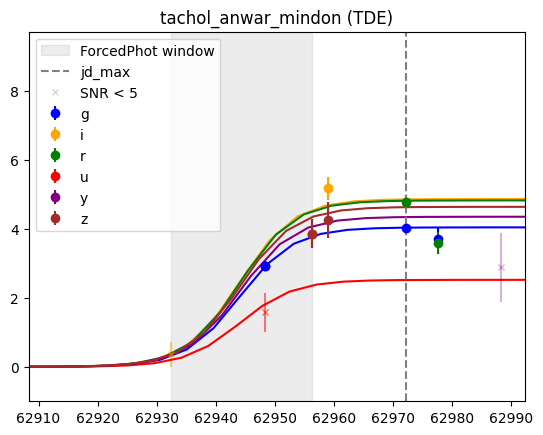

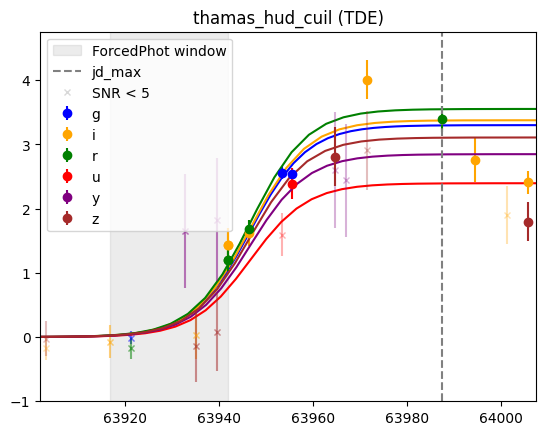

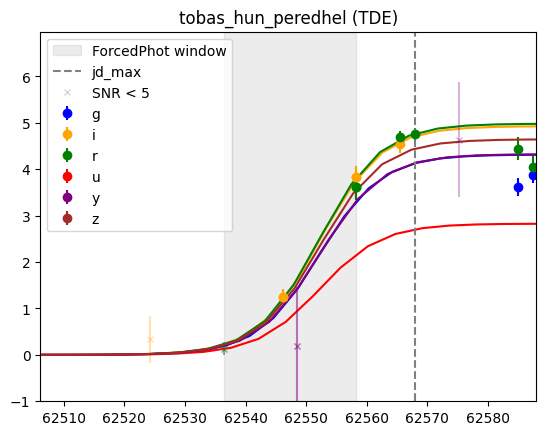

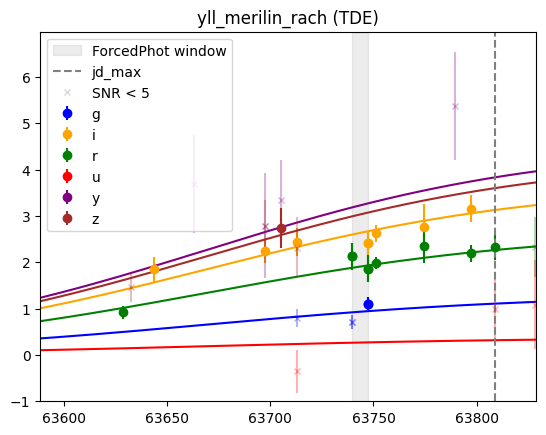

In [80]:
generate_plots(lcs_tdes, features)

# **Plot SNe with r_chisq > 9**

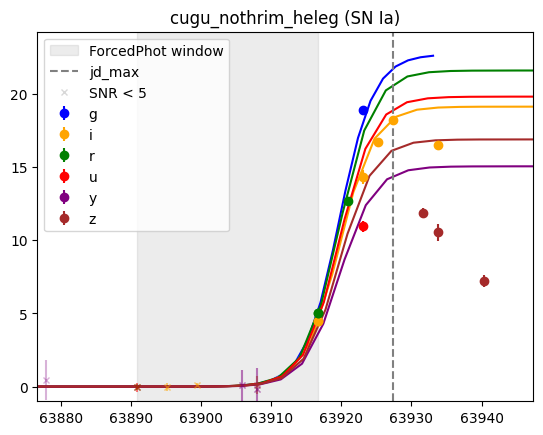

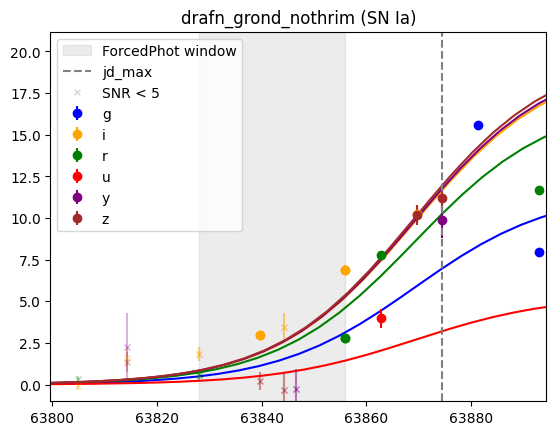

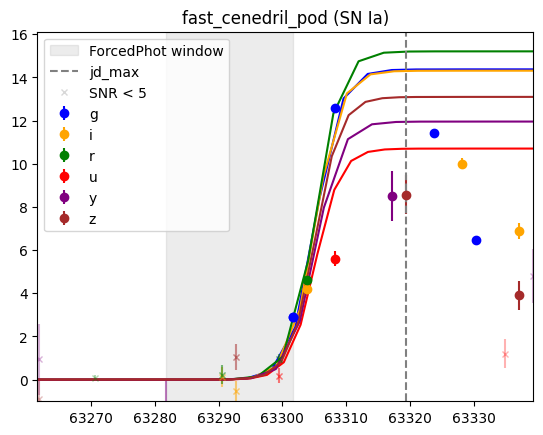

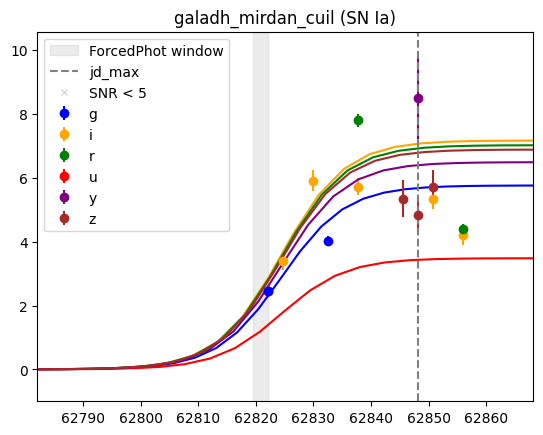

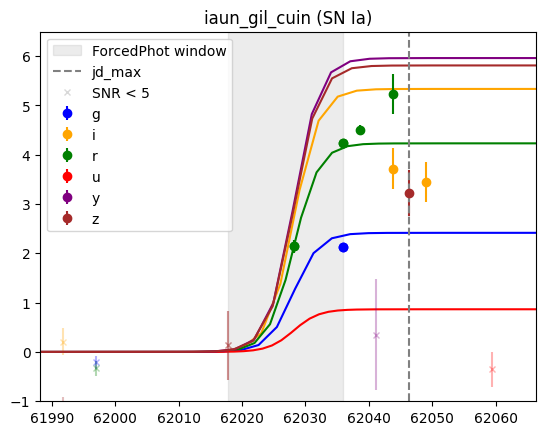

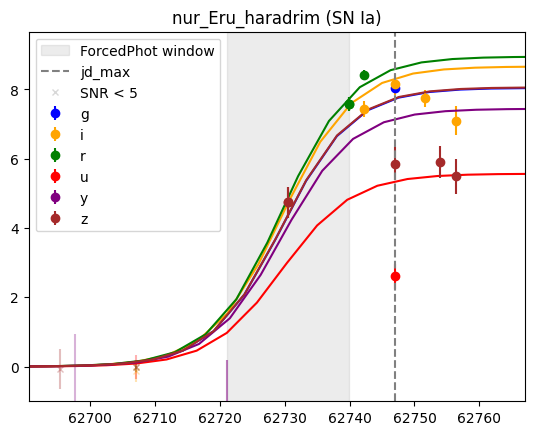

In [81]:
generate_plots(lcs_sn, features)